In [1]:
from statsmodels.formula.api import ols
from scipy import stats
import statsmodels.formula.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

In [2]:
np.random.seed(7)

df = pd.DataFrame({
    'exercise': [2,3,1,5,4,6,2,7,3,4,5,1,6,3,2,4,7,5,3,6,
                 2,4,1,5,3,6,4,2,7,3,5,4,6,2,3,7,4,5,1,6,
                 3,2,5,4,6,3,7,2,4,5,6,3,4,2,7,5,3,6,4,2,
                 5,4,3,6,2,7,4,5,3,6,2,4,5,3,7,6,4,2,5,3,
                 6,4,2,7,5,3,4,6,2,5,4,3,7,6,5,2,4,3,6,5],
    'satisfaction': [4,5,3,7,6,8,4,9,5,6,7,3,8,5,4,6,9,7,5,8,
                     4,6,3,7,5,8,6,4,9,5,7,6,8,4,5,9,6,7,3,8,
                     5,4,7,6,8,5,9,4,6,7,8,5,6,4,9,7,5,8,6,4,
                     7,6,5,8,4,9,6,7,5,8,4,6,7,5,9,8,6,4,7,5,
                     8,6,4,9,7,5,6,8,4,7,6,5,9,8,7,4,6,5,8,7],
    'department': ['HR','IT','HR','IT','FIN','IT','HR','FIN','IT','FIN']*10
})

In [3]:


print(f'The means of the satisfaction scores are: {df.groupby(['department'])['satisfaction'].mean()}')

The means of the satisfaction scores are: department
FIN    6.40
HR     6.10
IT     6.05
Name: satisfaction, dtype: float64


In [4]:
print(f'The median of the satisfaction scores are: {df.groupby(['department'])['satisfaction'].median()}')

The median of the satisfaction scores are: department
FIN    7.0
HR     6.0
IT     6.0
Name: satisfaction, dtype: float64


In [5]:
print(f'The std of the satisfaction scores are: {df.groupby(['department'])['satisfaction'].std().round(2)}')

The std of the satisfaction scores are: department
FIN    1.69
HR     1.75
IT     1.69
Name: satisfaction, dtype: float64


<Axes: xlabel='department', ylabel='satisfaction'>

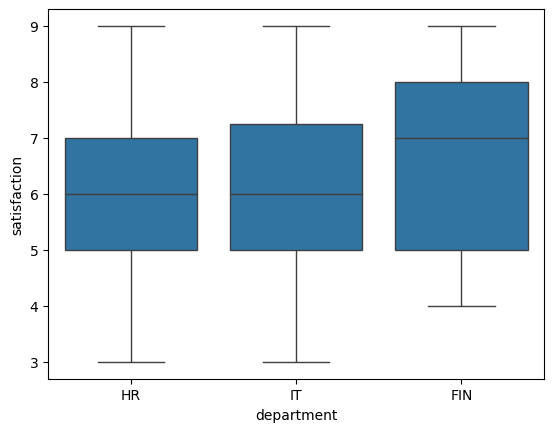

In [6]:
# Question 2

sns.boxplot(x=df.department, y=df.satisfaction)

In [7]:
# Question 3

# sample mean
mean = df.satisfaction.mean()

# variance
var = df.satisfaction.var()

print(f'The mean is: {mean:.2f} \nThe variance is: {var:.2f}')

The mean is: 6.17 
The variance is: 2.89


In [8]:
# Question 4 / Step 4

results = stats.ttest_1samp(a=df.satisfaction, popmean=5)

print(f'The t-stat is: {results.statistic:.4f}')
print(f'The p-value is: {results.pvalue:.9f}')

The t-stat is: 6.8824
The p-value is: 0.000000001


In [9]:
# Question 4 / Step 5 (Cohen's d)

print(f'The effect size is: {(mean-5)/np.sqrt(var):.2f}')

The effect size is: 0.69


In [10]:
# Question 5

mod = ols(formula= 'satisfaction ~ exercise', data=df)
fit = mod.fit()

print(fit.summary())

                            OLS Regression Results                            
Dep. Variable:           satisfaction   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.035e+31
Date:                Wed, 27 May 2026   Prob (F-statistic):               0.00
Time:                        13:17:18   Log-Likelihood:                 3200.8
No. Observations:                 100   AIC:                            -6398.
Df Residuals:                      98   BIC:                            -6392.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.0000   8.17e-16   2.45e+15      0.0

In [11]:
# Exercise 1

result = (3.4-4)/(1.2/np.sqrt(30))

print(f'The t-statistic is: {result:.4f}')
print(f'The p-value is: {stats.t.cdf(x=result, df= 29)*2:.4f}')

The t-statistic is: -2.7386
The p-value is: 0.0104


In [12]:
# Cohen's d

Cd = (3.4-4)/1.2

print(f'The effect size is: {Cd:.2f}')

The effect size is: -0.50


In [13]:
# Improving coding skills
# 1. Bernoulli

stats.binom.rvs(n=20, p=0.6)

15

In [14]:
# 2. Binomial

stats.binom.pmf(k=12, n=20, p=0.6)

np.float64(0.17970578775468965)

In [15]:
# 3. Poisson

stats.poisson.pmf(k=30, mu=25)

np.float64(0.04541278513011904)

In [16]:
stats.binom.cdf(k=12, n=20, p=0.6)

np.float64(0.5841070624424645)

In [17]:
1 - stats.poisson.cdf(k=30, mu=25)

np.float64(0.1366911308473362)

In [18]:
stats.poisson.rvs(mu=30, size=18)

array([35, 31, 20, 30, 35, 19, 39, 29, 42, 31, 23, 34, 29, 30, 30, 36, 27,
       26])

In [19]:
stats.poisson.cdf(k=110, mu= 100) - stats.poisson.cdf(k=90, mu= 100)

np.float64(0.6814775322359689)

In [20]:
import numpy as np
from scipy import stats

np.random.seed(42)
x = np.array([12.3, 9.8, 11.5, 14.2, 10.1, 13.7, 9.2, 11.8, 12.9, 10.5])

In [39]:
x = np.array([3.2, 5.1, 2.8, 4.4, 6.0, 3.7, 5.5, 4.1])

resamples = 10000

sample_boot = np.zeros(resamples)

for i in range(0, resamples):
    nvalue = np.random.choice(x, size= len(x), replace=True)
    sample_boot[i] = nvalue.mean()

print('The sampled mean is:',sample_boot.mean().round(2))
print('The 97.5th percentile is', np.percentile(sample_boot, 97.5).round(2))
print('The 2.5th percentile is:', np.percentile(sample_boot, 2.5))

The sampled mean is: 4.36
The 97.5th percentile is 5.09
The 2.5th percentile is: 3.6496874999999998


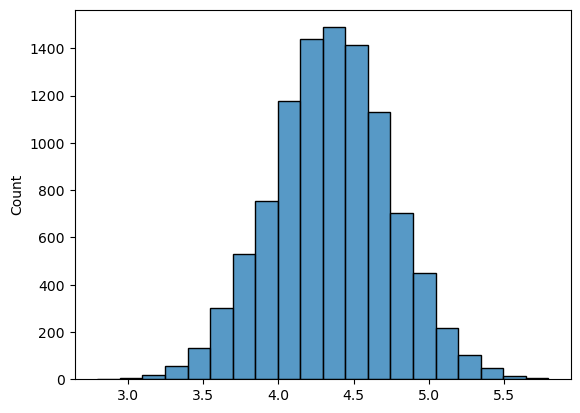

4.348675942629011
Bootstrap SE:   0.3952917513087205
95% CI:         [3.56834777 5.12243509]


In [37]:
x = np.array([3.2, 5.1, 2.8, 4.4, 6.0, 3.7, 5.5, 4.1])

resamples = 10000
n = len(x)

sample_boot = np.zeros(resamples)

mu_hat = x.mean()
sigma_hat = x.std(ddof=1)

# Bootstrapping the resamples
for i in range(resamples):
    resample = stats.norm.rvs(loc=mu_hat, size=n, scale=sigma_hat)
    sample_boot[i] = resample.mean()


sns.histplot(data=sample_boot, bins= 20)
plt.show()

print(sample_boot.mean())
print("Bootstrap SE:  ", sample_boot.std())
print("95% CI:        ", np.percentile(sample_boot, [2.5, 97.5]))

In [58]:
# Poor: 45,  OK: 52,  Good: 56,  Excellent: 47

obsv = [45, 52, 56, 47]
exp = [50]*4

result = stats.chisquare(f_obs=obsv, f_exp=exp)

print('t-stat:', result.statistic)
print('p-value:', result.pvalue)


t-stat: 1.4799999999999998
p-value: 0.686893952875671


In [67]:
df = pd.DataFrame({'Pass': [60, 70], 'Fail': [40, 30]}, index=['self', 'group'])

result = stats.chi2_contingency(df, correction=False)

print(result.statistic)
print(result.pvalue)
print(result.dof)
print(result.expected_freq)

2.197802197802198
0.1382076669740215
1
[[65. 35.]
 [65. 35.]]


In [81]:

df = pd.DataFrame({'satisfied' : [30, 80, 60], 'unsatisfied' : [70, 20, 40]}, index=('Sales', 'Marketing', 'IT'))

chi2, p, dof, expected = stats.chi2_contingency(df, correction=False)

print(chi2)
print(p.round(12))
print(dof)
print(expected)

51.58371040723982
6e-12
2
[[56.66666667 43.33333333]
 [56.66666667 43.33333333]
 [56.66666667 43.33333333]]


In [83]:
observed = [25, 65, 48, 12]
expected = [0.20, 0.40, 0.30, 0.10]
n = 150
expected_counts = [p * n for p in expected]

chi2, p = stats.chisquare(f_obs=observed, f_exp=expected_counts)

print("Chi-squared statistic:", chi2.round(2))
print("p-value:", p.round(2))

Chi-squared statistic: 2.05
p-value: 0.56


In [100]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import test_proportions_2indep

result = proportions_ztest(count=180, nobs=1200, value=0.12, alternative='larger')


print(result)

(np.float64(2.910427500435995), np.float64(0.0018046734679727215))


In [123]:
# Trial exam
# Problem 2

exp = -0.027/50
var = 0.999/50

print(exp, var)

-0.00054 0.01998


In [140]:
# Positive gain n=50

1- stats.norm.cdf(x=0, loc=-0.027, scale= np.sqrt(0.01998))

np.float64(0.424257170544623)

In [ ]:
# Monte Carlo

np.random.seed(1234)

samples = 100000



sim = np.random.choice([1, -1],p=[18/37, 19/37], size=samples)



print(f'The expected gain is {sim.mean()} \nThe variance is: {sim.var()} \nThe probability of a positive gain is: {np.mean(sim > 0)}')


The expected gain is -0.02832 
The variance is: 0.9991979776000002 
The probability of a positive gain is: 0.48584


In [203]:
# Problem 3

tval = (21253-20000)/(2200/np.sqrt(45))

print('The t-stat is:', tval.round(4))
print('The pvalue is:', (1 - stats.t.cdf(tval, df= 44)).round(4))

The t-stat is: 3.8206
The pvalue is: 0.0002


In [206]:
tval2 = (5263-5000)/(700/np.sqrt(45))

print('The t-stat is:', tval2.round(4))
print('The pvalue is:', (1 - stats.t.cdf(tval2, df= 77.6)).round(4))

The t-stat is: 2.5204
The pvalue is: 0.0069


## Module 3 exercises

In [ ]:
# Problem 40

stats.norm.cdf(10.01,loc=10 ,scale=0.04/np.sqrt(16)) - stats.norm.cdf(9.99, loc=10, scale=0.04/np.sqrt(16))

np.float64(0.6826894921370756)

In [218]:
1 - stats.norm.cdf(10.01, loc=10, scale=0.04/np.sqrt(25))

np.float64(0.10564977366686001)

In [229]:
# Problem 41

stats.norm.cdf(0.19, loc=0.18, scale=0.06/np.sqrt(40)) - stats.norm.cdf(0.16, loc=0.18, scale=0.06/np.sqrt(40))

np.float64(0.8365722369182748)

In [230]:
stats.norm.cdf(0.19, loc=0.18, scale=0.06/np.sqrt(15)) - stats.norm.cdf(0.16, loc=0.18, scale=0.06/np.sqrt(15))

np.float64(0.6423446905561638)

In [ ]:
# Problem 42
# a)

print('p(X ≤ 3)', stats.norm.cdf(3, loc=2.65, scale=0.85/np.sqrt(25)))
print('p(2.65 ≤ X ≤ 3)', stats.norm.cdf(3, loc=2.65, scale=0.85/np.sqrt(25)) - stats.norm.cdf(2.65, loc=2.65, scale=0.85/np.sqrt(25)))

p(X ≤ 3) 0.980244426611219
p(2.65 ≤ X ≤ 3) 0.480244426611219


In [240]:
# Problem 42
# b)

stats.norm.ppf(q=0.99, loc=2.65, scale=0.85)

np.float64(4.627395692934714)

In [31]:
# Problem 47
import numpy as np

X = [4.2, 3.9, 5.1, 4.8, 4.3, 5.0, 3.7, 4.5, 4.9, 4.6]

np.random.seed(1234)

samples = 1000
theta_hat = np.var(X, ddof=0)

boot_var = np.zeros(samples)

for i in range(0, samples):
    boot = np.random.choice(X, len(X), replace=True)
    boot_var[i] = np.var(boot, ddof=0)

bias = np.mean(boot_var) - theta_hat

bias

np.float64(-0.01991089999999998)

In [40]:
# Problem 48
# a) 

p_black = 18/38

print('The chances of landing on black are:', round(p_black, 2))

The chances of landing on black are: 0.47


In [86]:
# b)

B = 1000
wallet = 100

np.random.seed(123)

p = [18/38, 20/38]
winnings = [1, -1]

results = np.zeros(B)

for i in range(B):
    balance = wallet
    while 0 < balance < 150:
        sim = np.random.choice(winnings, p=p)
        balance += sim
    results[i] = balance

print(np.mean(results == 0))
print(np.mean(results == 150))


0.998
0.002


## Module 4 exercises

### Problem 1.1

#### a)

H_0 = µ = 200 

H_a = µ > 200

alpha = 0.05

In [100]:
from scipy import stats

t_stat = (215-200)/(25/np.sqrt(30))

print(t_stat)
print('p-value:', 1 - stats.t.cdf(t_stat, 29))

3.286335345030997
p-value: 0.0013294992338676037


### Problem 1.2

#### a)

H_0 = µ = 250

H_a = µ > 250

In [101]:
# b)

t_stat = (270 - 250)/(90/np.sqrt(50))

p_value = 1 - stats.t.cdf(t_stat, df=49)

print(f'The t statistic is: {t_stat:.4f} \nThe p-value is: {p_value:.4f}')

The t statistic is: 1.5713 
The p-value is: 0.0613


#### c)
We fail to reject the null hypothesis as the p-value is above the significance value, thus with the data provided we cannot conclude that the new opt-in strategy has a significant impact

### Problem
#### a)

H_0 = µ = 2200

H_a = µ < 2200

alpha = 0.05

In [104]:
t_stat = (2100 -2200)/(250/np.sqrt(40))

p_value = stats.t.cdf(t_stat, df=39)

print(f'The t statistic is: {t_stat:.4f} \nThe p-value is: {p_value:.4f}')

The t statistic is: -2.5298 
The p-value is: 0.0078


### Problem 1.4
#### a)

H_0 = µ = 24

H_a = µ ≠ 24

In [107]:
# b)

t_stat = (23.5-24)/(1.2/np.sqrt(50))
p_value = 2 * stats.t.cdf(t_stat, df= 49)

print(f'The t statistic is: {t_stat:.4f} \nThe p-value is: {p_value:.4f}')

The t statistic is: -2.9463 
The p-value is: 0.0049


### Problem 1.5
#### a)

H_0 = µ = 70

H_a = m < 70

In [127]:
# b) 

sample = [68, 72, 69,  71,  67,  65, 70, 66, 68, 64]

mu = np.mean(sample)
s = np.std(sample)

In [121]:
# c)

t_stat = (mu-70)/(s/np.sqrt(10))
p_value = stats.t.cdf(t_stat, df=9)

print(f'The t statistic is: {t_stat:.4f} \nThe p-value is: {p_value:.4f}')

The t statistic is: -2.5820 
The p-value is: 0.0148


### Problem 1.6

In [134]:
import numpy as np
x = np.array([498, 495, 497, 496, 499, 498, 494, 496, 495, 497, 496, 495])

# a)

mu = np.mean(x)
s = np.std(x)

t_stat = stats.ttest_1samp(x, popmean=500, alternative='less')

print(f'The t statistic is: {t_stat.statistic} \nThe p-value is: {t_stat.pvalue:.4f}')

The t statistic is: -8.482095610516701 
The p-value is: 0.0000


### Problem 2.1

#### a)

H_0 = µ_1 = µ_2

H_a = µ_1 > µ_2 

In [139]:
# c)

t_stat = (120-105)/np.sqrt(((30**2)/40)+((28**2)/40))
p_value = 1- stats.t.cdf(t_stat, df=77.63164160330635)

print(f'The t statistic is: {t_stat:.4f} \nThe p-value is: {p_value:.4f}')

The t statistic is: 2.3118 
The p-value is: 0.0117


### Problem 2.7

In [145]:
A = np.array([85, 87, 83, 84, 89, 91])
B = np.array([78, 77, 79, 81, 76, 75, 80])

results = stats.ttest_ind(a= A, b=B, equal_var=False)

print(f'The t statistic is: {results.statistic:.4f} \nThe p-value is: {results.pvalue:.4f}')

The t statistic is: 5.6667 
The p-value is: 0.0003


### Problem 3.1
#### a)

H_0 = p = 0.6*400

H_a = p > 0.6*400

In [158]:
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import test_proportions_2indep

results, p = proportions_ztest(count=260, nobs=400, value=0.6, alternative='larger')

print(results)
print(p)

2.0965696734438386
0.018015843109116688


### Problem 3.2
#### a)

H_0 = p = 0.3

H_a = p > 0.3

In [159]:
# b)

stat, p = proportions_ztest(count=166, nobs=500, value=0.3, alternative='larger')

print(stat)
print(p)

1.5194195406690882
0.06432846321412394


### Problem 3.3
#### a)

H_0 = p = 0.7

H_a = p > 0.7

In [160]:
# b)

stat, p = proportions_ztest(count=435, nobs=600, value=0.7, alternative='larger')

print(stat)
print(p)

1.3714509626474845
0.08511721003045147


### Problem 3.4
#### a)

H_0 = p ≤ 0 

H_a = p > 0

In [161]:
# b)

stat, p = proportions_ztest(count=7, nobs=80, value=0.05, alternative='larger')

print(stat)
print(p)

1.1870138823733958
0.11761107236064738


### Problem 4.1
#### a)

H_0 = p_1 = p_2

H_a = p_1 > p_2

In [165]:
# c)

stat, p = test_proportions_2indep(count1=0.45*200, nobs1=200, count2=0.35*200, nobs2=200, alternative='larger')

print(stat)
print(p)

2.040715345593312
0.020639564576497973


### Problem 4.2
#### a)

H_0 = p_A = p_B

H_a = p_A > p_B

In [178]:
# b

stat, p = test_proportions_2indep(count1=231, nobs1=483, count2=191, nobs2=469, alternative='larger')

print(stat)
print(p)

2.206184457144477
0.013685543549074473


In [168]:
# Economical significance

print(f'{191/469 - 231/483}')

-0.07101140261425792


### Problem 4.3
#### a)

H_0 = p_n = p_o
H_1 = p_n > p_o

In [180]:
z, p = test_proportions_2indep(count1=210, nobs1=500, count2=180, nobs2=500, alternative='larger')

print(z)
print(p)

1.944399615030605
0.02592364012924071


In [189]:
# Problem 2
# a)
# we need to analyse the spread and the probability that the value lies outside of the mean 
print('P (x < 100)', stats.norm.cdf(100, loc=100, scale=15))

# b)
print('P (x < 115)', stats.norm.cdf(115, loc=100, scale=15))

# c)
print('Z:', (115-100)/15)

P (x < 100) 0.5
P (x < 115) 0.8413447460685429
Z: 1.0


In [192]:
# Problem 4

2*stats.norm.cdf(-1.96)

np.float64(0.04999579029644087)

<Axes: ylabel='Count'>

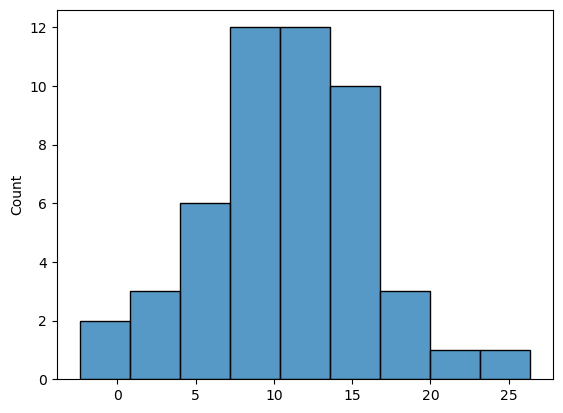

In [ ]:
# Problem 5
import matplotlib.pyplot as plt
import seaborn as sns


results = stats.norm.rvs(loc=10, scale=5, size=50)


sns.histplot(results)

In [203]:
1 - stats.norm.cdf(11, loc=10, scale=5/np.sqrt(50))

np.float64(0.0786496035251425)

In [219]:
# Problem 10

#a)
print(1 - stats.norm.cdf(1.96, loc=0, scale=1))
print(stats.norm.cdf(1.64, loc=0, scale=1) - stats.norm.cdf(-1.64, loc=0, scale=1))
print(1 - stats.norm.cdf(120, loc=100, scale=15))

0.024997895148220484
0.8989948330517925
0.09121121972586788


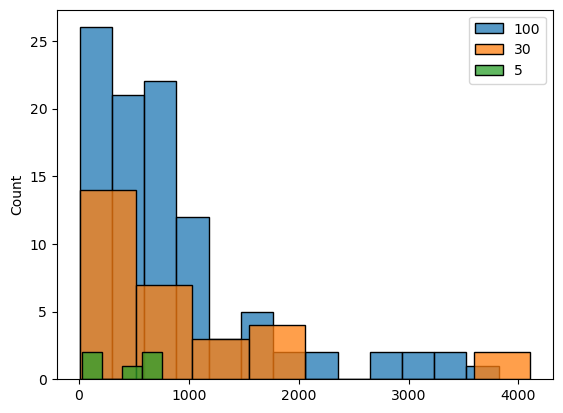

In [242]:
# Problem 11
# a)

sns.histplot(stats.expon.rvs(size=100, scale=1000))
sns.histplot(stats.expon.rvs(size=30, scale=1000))
sns.histplot(stats.expon.rvs(size=5, scale=1000))
plt.legend([100, 30, 5])
plt.show()

In [ ]:
# Problem 12

mu = 0
n_val = [5, 10, 30]
t_stats = {}

for n in n_val:
    

TypeError: _parse_args_rvs() missing 1 required positional argument: 'df'

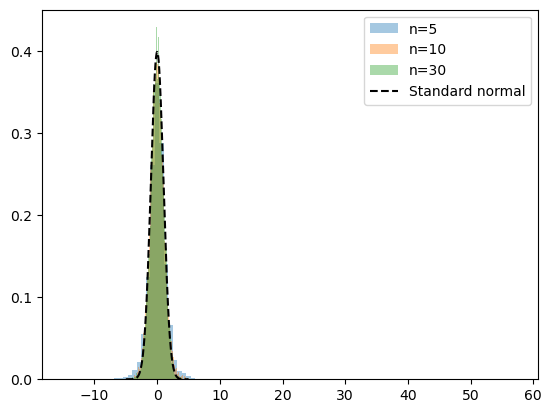

In [244]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

mu = 0  # true mean
n_values = [5, 10, 30]
t_stats = {}

for n in n_values:
    t_list = []
    for _ in range(10000):
        sample = stats.norm.rvs(loc=mu, scale=1, size=n)
        t = (sample.mean() - mu) / (sample.std(ddof=1) / np.sqrt(n))
        t_list.append(t)
    t_stats[n] = t_list

# Plot
x = np.linspace(-5, 5, 200)
for n in n_values:
    plt.hist(t_stats[n], bins=100, density=True, alpha=0.4, label=f'n={n}')

plt.plot(x, stats.norm.pdf(x), 'k--', label='Standard normal')
plt.legend()
plt.show()

In [249]:
# Problem 13

# a)
print(1 - stats.t.cdf(2.015, df=5))

# b)
print(2* stats.t.cdf(-2.228, df=10))
 

0.0500030861634031
0.050011771817111306


In [254]:
# Problem 14

# 4
print(stats.norm.ppf(0.975))

1.959963984540054


In [258]:
# Problem 15

# a)
print(1 - stats.norm.cdf(240, loc=200, scale=30))

# b)

print(stats.norm.cdf(220, loc=200, scale=30) - stats.norm.cdf(160, loc=200, scale=30))

# c)
print(stats.norm.ppf(0.95, loc=200, scale=30))

0.09121121972586788
0.6562962427272092
249.34560880854417


In [266]:
# Problem 16

# a)
print(stats.t.cdf(2.18, df=12))

# b)
print(2*(1-stats.t.cdf(2.18, df=12)))

# c)
print(stats.t.ppf(0.975, df=12))

0.9750530883473195
0.04989382330536096
2.1788128296634177


In [271]:
# Problem 17

# a)
print(1-stats.norm.cdf(-0.5, loc=0, scale=1))

# b)
print(stats.norm.cdf(0.84, loc=0, scale=1))

# c)
print(stats.norm.cdf(1.28, loc=0, scale=1))

0.6914624612740131
0.7995458067395503
0.8997274320455579


In [274]:
# Problem 18

# a)
print(stats.norm.pdf(1))

# b)
print(stats.t.pdf(1, df=5))

0.24197072451914337
0.2196797973509805


In [285]:
# Monte Carlo

sim = 10000
n = 100
p = 1/6


result = np.zeros(sim)

for i in range(sim):
    rolls = np.random.randint(1, 7, size=n)
    result[i] = np.sum(rolls == 6)/n

result.mean()

np.float64(0.16684699999999997)

<Axes: ylabel='Count'>

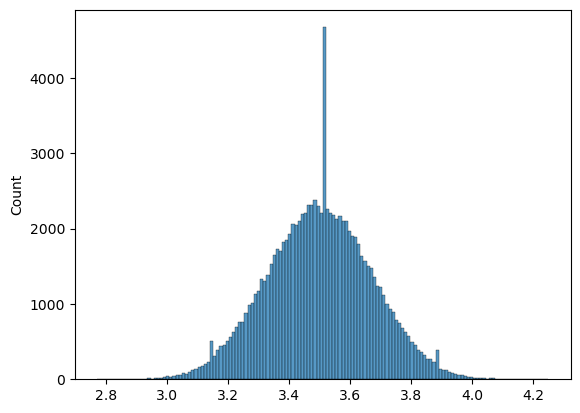

In [319]:
# Monte Carlo

sim = 100000
n = 100
p = 1/6


result = np.zeros(sim)

for i in range(sim):
    rolls = np.random.randint(1, 7, size=n)
    result[i] = np.mean(rolls)

sns.histplot(result)

In [ ]:
n = 10000
values = [0, 1]
p = [0.5,0.5]
throws = 50

np.random.seed(123)

result = np.zeros(n)

for i in range(n):
    sample = np.random.choice(a=values, p=p, size=throws)
    result[i] = np.sum(sample)

print('P(heads = 25):', np.mean(result == 25))
print('P(heads ≥ 30):', np.mean(result >= 30))
print('E(heads)', result.mean(), '\nStd:', result.std())

P(heads = 25): 0.1055
P(heads ≥ 30): 0.1028
E(heads) 25.02 
Std: 3.5423156268181413


In [346]:
n = 10000
returns = [0.05, -0.03]
p = [0.6, 0.4]

np.random.seed(123)

days = 30

sim = np.zeros(n)
paths = np.zeros((n, days))

nlist = []

for i in range(n):
    balance = 1000
    for _ in range(days):
        sample = np.random.choice(a=returns, p=p)
        balance += balance*sample
        paths[i, _] = balance
    sim[i] = balance

print('The expected value after 30 days is:', sim.mean())
print('P(X > 1000)', np.mean(sim > 1000))
print('C:', np.mean(paths.min(axis=1) < 800))

The expected value after 30 days is: 1705.39229222191
P(X > 1000) 0.991
C: 0.0041


In [355]:
n = 10000
rounds = 20
rolls = [-0.2, 0.15, 0.3]
p = [2/6, 2/6, 2/6]

sample_values = np.zeros(n)
eliminated = np.zeros(n)

for i in range(n):
    balance = 500
    for r in range(rounds):
        sample = np.random.choice(rolls, p=p)
        balance += balance*sample
        if balance <= 100:
            eliminated[i] = 1
            break
        else:
            continue
    sample_values[i] = balance

print('Expected final balance:', np.mean(sample_values))
print('Probability of being eliminated before the 20th round', np.mean(eliminated))
print('P(X > 1000)', np.mean(sample_values > 1000))

Expected final balance: 2484.4386900629192
Probability of being eliminated before the 20th round 0.0029
P(X > 1000) 0.7206


### Retake exam

In [389]:
# Problem 3

# a)
Jugs = [0, 1, 2, 3, 4, 5, 6]
p = [0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03]

p_day = 0

for i in range(len(Jugs)):
    if Jugs[i] != 0:
        p_day += p[i]

round(p_day**7, 4)

0.6983

In [488]:
exp = np.zeros(len(Jugs))

for i in range(len(Jugs)):
    exp[i] = Jugs[i] * p[i]

E = np.sum(exp)

exp2 = np.zeros(len(Jugs))

for i in range(len(Jugs)):
    exp2[i] = (Jugs[i]-E)**2 * p[i]

var = np.sum(exp2)
std = np.sqrt(var)

print('E(x):', E)
print('Var(x):', std)

E(x): 2.6300000000000003
Var(x): 1.3831485820402667


In [491]:
stats.norm.cdf(3500, loc=E*365*3.75, scale=std*np.sqrt(365)*3.75)

np.float64(0.15690670053323635)

He averages an income of 17998.261875 per year


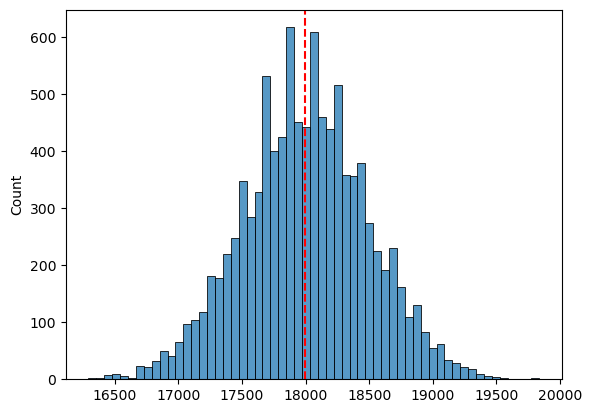

In [486]:
# Monte Carlo

n = 10000
Jugs = [0, 1, 2, 3, 4, 5, 6]
p = [0.05, 0.15, 0.30, 0.25, 0.15, 0.07, 0.03]


total_sim = np.zeros(n)

for i in range(n):
    sim = np.random.choice(Jugs, p=p, size=365, replace=True)
    total_sim[i] = np.sum(sim)*5*3.75

print('He averages an income of', total_sim.mean(), 'per year')
sns.histplot(total_sim)
plt.axvline(E*5*365*3.75, color='red', linestyle='--')
plt.show()

In [454]:
# Problem 4
import pandas as pd

# b)
Fewstorks =  [4, 1, 2]
Manystorks  = [5, 2, 3]


df = pd.DataFrame(data=(Fewstorks, Manystorks), index=('Fewstorks', 'Manystorks'), columns=('LowBR', 'MedBR', 'HighBR'))

results = stats.chi2_contingency(observed=df)

print('The chi2 statistic:', results.statistic)
print('Degrees of freedom:', results.dof)
print('p-value:', results.pvalue)



The chi2 statistic: 0.1187301587301587
Degrees of freedom: 2
p-value: 0.9423626691840816


In [492]:
# c)

correlation = stats.pearsonr(x=Fewstorks, y=Manystorks)

print('Corr:', correlation.statistic)
print('p-value:', correlation.pvalue)

Corr: 0.9999999999999997
p-value: 1.8972747694479864e-08


### Module 5 exercises

In [ ]:
# Problem 1

obs = np.array([[30, 20, 50],[40, 10, 50]])

res = stats.chi2_contingency(obs)

print(res.statistic)
print(res.pvalue)

4.761904761904762
0.09246247606291999


In [508]:
# Problem 2

#c)
Face = [1, 2, 3, 4, 5, 6]  
Freq = [10, 12, 9, 11, 8, 10]

throws = 60
exp = [60/6]*6

chi = stats.chisquare(f_obs=Freq, f_exp=exp,)

print(chi.statistic)
print(chi.pvalue)

1.0
0.9625657732472964


In [516]:
# Problem 3

Male = [30, 20]
Female = [20, 30]

table = np.array([Male, Female])

#exp = [(Male[i]*Female[i])/100 for i in range(len(Male))]

stats.chi2_contingency(observed=table, correction=False)

Chi2ContingencyResult(statistic=np.float64(4.0), pvalue=np.float64(0.045500263896358445), dof=1, expected_freq=array([[25., 25.],
       [25., 25.]]))

In [529]:
# Bootstrap exercise

n = 10000
scores = [62, 75, 81, 90, 55, 70, 88, 66]
length = len(scores)

boot = np.zeros(n)

for i in range(n):
    boot_sample = np.random.choice(a=scores, size=len(scores), replace=True)
    boot[i] = np.mean(boot_sample)

mean = np.mean(boot)
std = np.std(boot)

cv = stats.t.ppf(q=1-0.05/2, df=len(scores)-1) # critical value
                 
CI_upper = np.percentile(boot, 97.5)
CI_lower = np.percentile(boot, 2.5)

print('The mean is:', mean)
print('The CI upper is:', CI_upper)
print('The CI lower is:', CI_lower)


The mean is: 73.391325
The CI upper is: 81.5
The CI lower is: 65.375


In [534]:
# Bootstrap exercise 2

n = 10000

output = [120, 135, 128, 142, 119, 131]

boot_sample = np.zeros(n)

for i in range(n):
    sample = np.random.choice(output, size=len(output), replace=True)
    boot_sample[i] = np.var(sample, ddof=1)

print('The variance is:', np.mean(boot_sample))
print('The confidence interval is [', np.percentile(boot_sample, 2.5), np.percentile(boot_sample, 97.5),']')

The variance is: 64.93257666666666
The confidence interval is [ 16.166666666666664 126.66666666666666 ]


In [ ]:
# Parametric bootstrap exercis

n = 10000
lifetimes = [850, 920, 780, 1010, 890, 960, 830]

boot = np.zeros(n)

for i in range(n):
    sample = stats.norm.rvs(loc=np.mean(lifetimes), scale=np.std(lifetimes, ddof=1), size=len(lifetimes))
    boot[i] = np.mean(sample)

print('The mean is:', np.mean(boot))
print('The CI interval is:', np.percentile(boot, 2.5), np.percentile(boot, 97.5))



The mean is: 891.856814916227
The CI interval is: 834.3319010204439 949.6907306290288


### TECH3 exam

#### Problem 3

In [20]:
from statsmodels.formula.api import ols
from scipy import stats
import statsmodels.formula.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd

# a)
Part = np.array([0, 1, 2, 3, 4])
p = np.array([0.10, 0.25, 0.30, 0.20, 0.15])

p_1 = 1-0.1
p_5 = stats.binom.pmf(k=5,n=5 ,p=p_1)

print('p(X=1):', p_1)
print('p 5 weeks(X=1):', p_5.round(2))

p(X=1): 0.9
p 5 weeks(X=1): 0.59


In [25]:
# b)
EX = np.sum(Part * p)
EX2 = np.sum(Part**2 * p)
Var = EX2 - EX**2

print('The expected value is:', np.round(EX, 2))
print('The std is:', np.round(np.sqrt(Var), 2))
 

The expected value is: 2.05
The std is: 1.2


In [31]:
# d)
# Monte Carlo simulation

n = 10000
Part = np.array([0, 1, 2, 3, 4])
p = np.array([0.10, 0.25, 0.30, 0.20, 0.15])
dur = 52

sim = np.zeros(n)


for i in range(n):
    balance = -50000
    for d in range(dur):
        sample = np.random.choice(a=Part, p=p)
        balance += sample*2200-sample*250-4200
    if balance < 0:
        sim[i] = True

sim.mean()

np.float64(0.9998)

#### Problem 4

In [37]:
# a)

obs = np.array([[380, 342], [144, 163 ]])

chi, p, df, exp = stats.chi2_contingency(obs, correction=False)

print('The chi2 value is:', chi)
print('Degrees of freedom:', df)
print('The p-value is:', p)


The chi2 value is: 2.82603322519884
Degrees of freedom: 1
The p-value is: 0.09274718833993427


In [63]:
proportions_ztest(count=(163,144), nobs=(505,524), alternative='larger')

(np.float64(1.681080969257234), np.float64(0.04637359416996705))